# Project: Image Captioning using Deep Learning

## 1. Importing Libraries

In [4]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm  # Progress bar library for Jupyter Notebook
import matplotlib.pyplot as plt
from PIL import Image ## PIL stands for Python Imaging Library. It is a library for working with images in Python.
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input ## Pre-trained model for image feature extraction
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer ## Tokenizer class for captions tokenization
from tensorflow.keras.preprocessing.sequence import pad_sequences ## Function for padding sequences to a specific length

## Class for defining Keras models
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical,plot_model
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add

In [16]:
## Setting up Base directory and Working directory path
Base_dir='/kaggle/input/datasets/adityajn105/flickr8k' 
working_dir='/kaggle/working/'

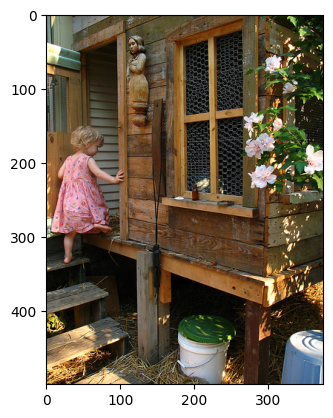

In [17]:
image_name = "1000268201_693b08cb0e.jpg"
image_id = image_name.split('.')[0] ## removing the extension of image file like.jpg
img_path = os.path.join(Base_dir, "Images", image_name)
image = Image.open(img_path)
plt.imshow(image)

In [21]:
## Load the caption dataset
data = pd.read_csv("/kaggle/input/datasets/adityajn105/flickr8k/captions.txt")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## Image Features Extraction

When it comes to understanding images, we need a helping hand from specialized models. Here's where the pre-trained VGG16 (Transfer Learning) model steps in. This model is like a superhero for extracting important details from images, helping us understand what's happening.

**Why VGG16?** 

VGG16 is popular because it has a knack for extracting both simple and complex features from images. Think of it as an image interpreter. It can tell us about the cat's pointy ears, its fluffy fur, and even the windowsill it's sitting on.

With the image features extracted by VGG16, we'll be able to merge the world of images and words, creating meaningful captions that describe the pictures as if the computer were telling a story.

In [22]:
model=VGG16() # Load the vgg16 model

# Restructuring the model to remove the last classification layer, this will give us access to the output features of the model
model=Model(inputs=model.inputs, outputs=model.layers[-2].output)

# Printing the model summary
print(model.summary())

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [25]:
features={} # Initialize an empty dictionary to store image features

# Define the directory path where images are located
directory=os.path.join(Base_dir,'Images')

# Loop through each image in the directory
for img_name in tqdm(os.listdir(directory)):
    # Load the image from file
    img_path=directory +'/'+ img_name
    image=load_img(img_path,target_size=(224,224))
    # Convert image pixels to a numpy array
    image=img_to_array(image)
    # Reshape the data for the model
    image=image.reshape(1,image.shape[0],image.shape[1],image.shape[2])
    # Preprocess the image
    image=preprocess_input(image)
    # Extract features using the pre-trained model
    feature=model.predict(image,verbose=0)
    # Get the image ID by removing the file extension
    image_id=img_name.split('.')[0]
    # Store the extracted feature in the dictionary with the image ID as the key
    features[image_id]=feature


  0%|          | 0/8091 [00:00<?, ?it/s]

## 3. Text Preprocessing

In [26]:
## Opening the captions text file
with open(os.path.join(Base_dir,'captions.txt'),'r') as File:
    next(File)
    captions_file=File.read()

In [28]:
## Dictionary mapping image IDs to their captions
mapping = {}
for line in tqdm(captions_file.split('\n')):
    tokens = line.split(',')
    #Skips lines with fewer than 2 characters (likely blank lines)
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    image_id = image_id.split('.')[0]
    caption = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    mapping[image_id].append(caption)

  0%|          | 0/40456 [00:00<?, ?it/s]

In [30]:
# Function for processing the captions
def preprocessing(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i].lower()
            caption = caption.replace('[^A-Za-z]', '')
            caption = caption.replace('\s+', ' ')
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word) > 1]) + ' endseq'
            captions[i] = caption

preprocessing(mapping)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_58/3415799150.py:7: SyntaxWarning: invalid escape sequence '\s'
  caption = caption.replace('\s+', ' ')


## 4. Tokenization and Splitting

In [32]:
#Used to extract all captions from the mapping dictionary into a single list
all_captions = [caption for key in mapping for caption in mapping[key]]

In [33]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions)

## 5. Splitting data into train and test

In [34]:
# Get the image IDs
image_ids = list(mapping.keys())

# Split into train and test sets (90% train, 10% test)
train, test = train_test_split(image_ids, test_size=0.1, random_state=42)

## 6. Data Generation (To Avoid Memory Issues)

In [35]:
## Data generator function
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    ## List to store batch data
    X1, X2, y = [] , [] ,[] 
    n = 0 ## Counter for the current batch size
    while True:
        ## Loop through each image in the current batch
        for key in data_keys:
            ## Get the captions associated with the current image
            captions = mapping[key]
            
            ## Loop through each caption for the current image
            for caption in captions:
                ## convert the captions into a sequence of token IDs
                seq = tokenizer.texts_to_sequences([caption])[0]

                ## Loop through the tokens in the caption sequence
                for i in range(1, len(seq)):
                    ## Split the sequence into input and output pairs
                    in_seq, out_seq = seq[:i], seq[i]
                    ## Pad the input sequence to the specified maximum caption length
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    ## Convert the output sequence to one-hot encoded format
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    ## Append data to batch lists
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            ## Increase the batch counter
            n += 1
            ## If the batch is complete, yield the batch and reset lists and counter
            if n == batch_size:
                yield {"image": np.array(X1), "text": np.array(X2)}, np.array(y)
                X1.clear()  # Clears the content of X1
                X2.clear()  # Clears the content of X2
                y.clear()   # Clears the content of y
                n = 0

## 7. Model Architecture

**LSTM Model Training**

We've got our image features, and we're ready to make our captions come to life.we'll be diving into the training of our LSTM model. This is where the real magic happens as we teach our model to generate descriptive captions for our images.

In [36]:
# image feature layers
#4096 is the output of second last layer of the vgg16
inputs1=Input(shape=(4096,),name="image")
a=Dropout(0.3)(inputs1)
X=Dense(256,activation='relu')(a)

# sequence feature layers
inputs2=Input(shape=(max_length,),name="text")
c=Embedding(vocab_size,256)(inputs2)
d=Dropout(0.3)(c)
Y=LSTM(256)(d)



decoder1=add([X , Y])
decoder2=Dense(256,activation='relu')(decoder1)
outputs=Dense(vocab_size,activation='softmax')(decoder2)

## Create the model
model=Model(inputs=[inputs1,inputs2],outputs=outputs)
model.compile(loss='categorical_crossentropy',optimizer='adam')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 37)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 4096)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 256)   │  2,172,160 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 37, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8485)      │  2,180,645 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,992,741 (22.86 MB)

 Trainable params: 5,992,741 (22.86 MB)

 Non-trainable params: 0 (0.00 B)

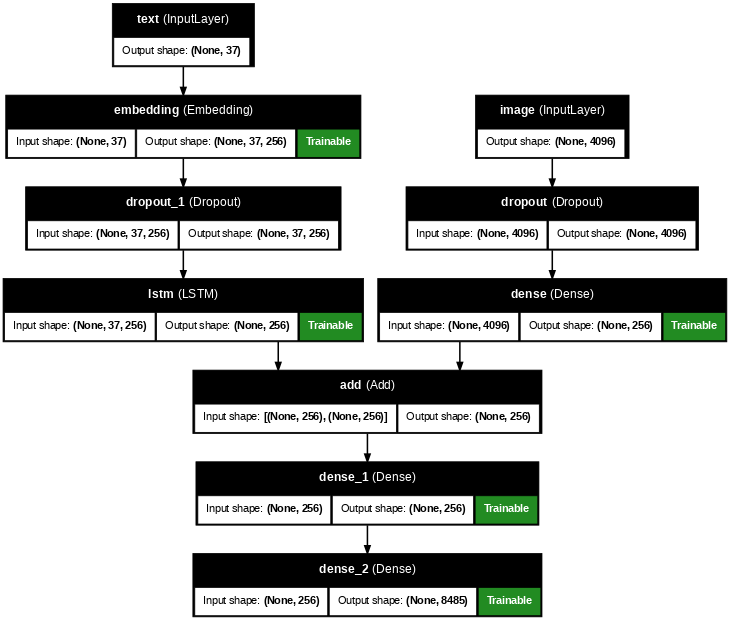

In [37]:
tf.keras.utils.plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    dpi=55,
    show_layer_activations=False,
    show_trainable=True
)

## 8. Training the Model

In [38]:
## Set the number of epochs, batch size
epochs=12
batch_size=32
steps=len(train)//batch_size

for i in range(epochs):
    generator=data_generator(train,mapping,features,tokenizer,max_length,vocab_size,batch_size)
    model.fit(generator, epochs=1,steps_per_epoch=steps,verbose=1)

227/227 ━━━━━━━━━━━━━━━━━━━━ 741s 3s/step - loss: 4.3273
227/227 ━━━━━━━━━━━━━━━━━━━━ 738s 3s/step - loss: 3.2717
227/227 ━━━━━━━━━━━━━━━━━━━━ 734s 3s/step - loss: 2.9281
227/227 ━━━━━━━━━━━━━━━━━━━━ 737s 3s/step - loss: 2.7013
227/227 ━━━━━━━━━━━━━━━━━━━━ 739s 3s/step - loss: 2.5351
227/227 ━━━━━━━━━━━━━━━━━━━━ 738s 3s/step - loss: 2.4147
227/227 ━━━━━━━━━━━━━━━━━━━━ 737s 3s/step - loss: 2.3301
227/227 ━━━━━━━━━━━━━━━━━━━━ 737s 3s/step - loss: 2.2568
227/227 ━━━━━━━━━━━━━━━━━━━━ 745s 3s/step - loss: 2.1914
227/227 ━━━━━━━━━━━━━━━━━━━━ 738s 3s/step - loss: 2.1325
227/227 ━━━━━━━━━━━━━━━━━━━━ 745s 3s/step - loss: 2.0828
227/227 ━━━━━━━━━━━━━━━━━━━━ 749s 3s/step - loss: 2.0358


## 9. Generate Captions for the Image 

In [39]:
def convert_to_word(number, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == number:
            return word
    return None


def predict_caption(model, image, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], max_length)
        y_pred = model.predict([image, sequence], verbose=0)
        y_pred = np.argmax(y_pred)
        word = convert_to_word(y_pred, tokenizer)
        if word is None:
            break
        in_text += " " + word
        if word == 'endseq':
            break
      
    return in_text

In [45]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    image_id = image_name.split('.')[0]
    img_path = os.path.join(Base_dir, "Images", image_name)
    image = Image.open(img_path)
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    # Remove duplicate startseq
    y_pred = y_pred.replace('startseq startseq', 'startseq')
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    print(y_pred)

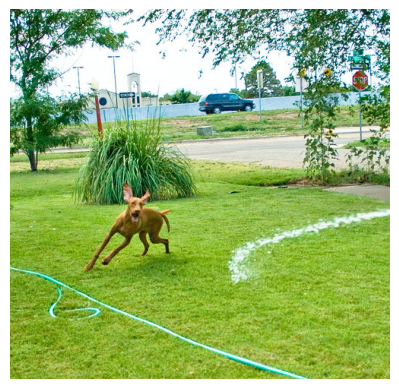

startseq brown dog is jumping on the grass endseq


In [46]:
generate_caption("1019077836_6fc9b15408.jpg")

## 10. BLEU Score

BLEU Score is an evaluation metric used to measure the quality of machine-generated text, especially in machine translation and image captioning.
BLEU Score ranges from 0-1 where 0 means Very poor similarity
and 1 means Very high similarity

In [42]:
from nltk.translate.bleu_score import corpus_bleu
# validate with test data
actual, predicted = [] , []

for key in tqdm(test):

    captions = mapping[key] 
    # predict the caption for image
    y_pred = predict_caption(model, features[key], tokenizer, max_length)
    # split into words
    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()
    # append to the list
    actual.append(actual_captions)
    predicted.append(y_pred)

    # calcuate BLEU score
#Unigram
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
#Bigram
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.588635
BLEU-2: 0.400207


## Saving the model

In [47]:
model.save('model.h5')

pickle.dump(tokenizer , open('tokenizer.pkl','wb'))